# **Echo Vision** 
## **Approach 1: Using Hugging Face Transformers pipelines**

In [ ]:
# ! pip install torch torchvision

In [ ]:
# ! pip install transformers tokenizers accelerate

In [ ]:
# ! pip install pillow matplotlib timm

### **1. Image Input**

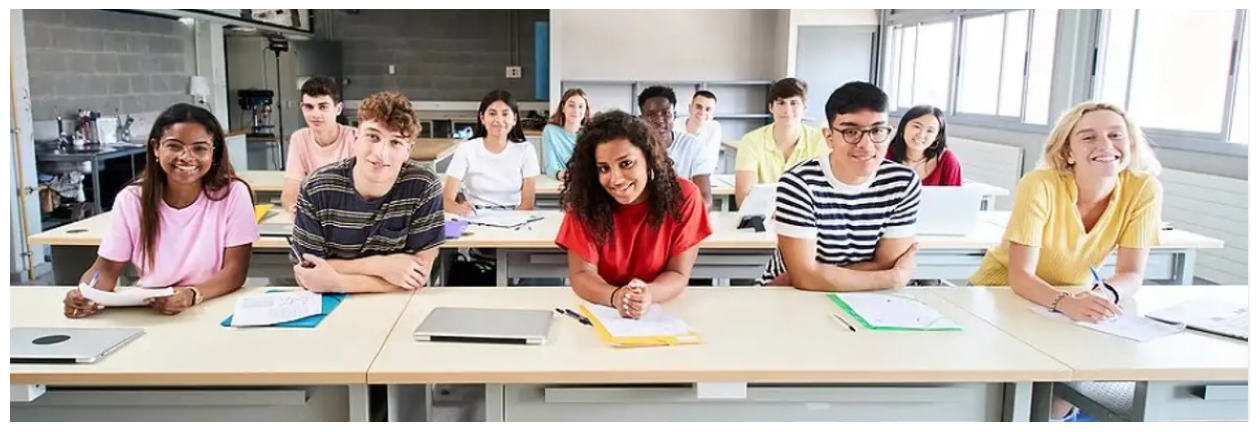

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = "images\\classroom.jpg"  
loadedImage = Image.open(image_path)

# Display the image
plt.figure(figsize=(16, 9))
plt.imshow(loadedImage)
plt.axis('off') 
plt.show()

### **2. Object Detection from Image**

In [2]:
from transformers import pipeline

# Initialize the object detection pipeline
objectDetector = pipeline(
    task="object-detection",
    model="facebook/detr-resnet-50",
)

# Perform object detection on the loaded image
detections = objectDetector(loadedImage)


d:\MyData\Work\AI Solution Enablement Program\Labs\Projects\echo_vision\.env_echo_vision\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 733.39it/s, Materializing param=model.query_position_embeddings.weight]                 
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNE

#### **2.1 List down the dected objects**

In [3]:
# Print the detected objects in table format with score, label, and bounding box coordinates
print(f"{'Label':<20} {'Score':<10} {'Bounding Box':<30}")
print("-" * 60)
for detection in detections:
    label = detection['label']
    score = detection['score']
    bbox = detection['box']
    print(f"{label:<20} {score:<10.4f} {str(bbox):<30}")

Label                Score      Bounding Box                  
------------------------------------------------------------
person               0.9798     {'xmin': 594, 'ymin': 72, 'xmax': 649, 'ymax': 180}
person               0.9957     {'xmin': 505, 'ymin': 74, 'xmax': 555, 'ymax': 165}
book                 0.5737     {'xmin': 225, 'ymin': 189, 'xmax': 267, 'ymax': 216}
chair                0.7470     {'xmin': 380, 'ymin': 123, 'xmax': 431, 'ymax': 149}
person               0.9981     {'xmin': 917, 'ymin': 83, 'xmax': 1103, 'ymax': 299}
laptop               0.8307     {'xmin': 850, 'ymin': 168, 'xmax': 961, 'ymax': 224}
person               0.9941     {'xmin': 252, 'ymin': 64, 'xmax': 333, 'ymax': 202}
person               0.9725     {'xmin': 602, 'ymin': 71, 'xmax': 669, 'ymax': 193}
laptop               0.6989     {'xmin': 386, 'ymin': 284, 'xmax': 525, 'ymax': 318}
person               0.9981     {'xmin': 407, 'ymin': 76, 'xmax': 505, 'ymax': 195}
person               0.9944    

#### **2.2 Draw the bounding box on the image**

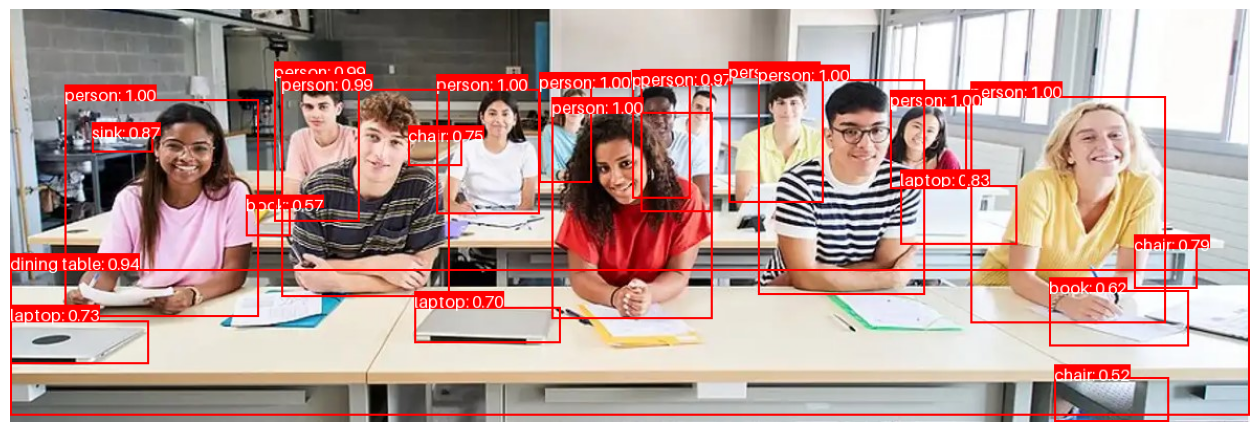

In [4]:
# Draw the bounding boxes on the image
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# Create a drawing context
loadedImageCopy = loadedImage.copy()  # Create a copy of the original image to draw on
draw = ImageDraw.Draw(loadedImageCopy)
font = ImageFont.load_default(16)

# Draw the bounding boxes with labels labels
for detection in detections:
    box = detection['box']
    label = detection['label']
    score = detection['score']
    
    # Define the rectangle coordinates
    xmin, ymin, xmax, ymax = box['xmin'], box['ymin'], box['xmax'], box['ymax']
    
    # Draw the rectangle
    draw.rectangle([(xmin, ymin), (xmax, ymax)], outline="red", width=2)
    
    # Prepare the label text
    text = f"{label}: {score:.2f}"
    
    # Get text size
    text_bbox = draw.textbbox((xmin, ymin), text, font=font)
    text_width = text_bbox[2] - text_bbox[0]
    text_height = text_bbox[3] - text_bbox[1]
    
    # Draw the text background rectangle
    draw.rectangle([(xmin, ymin - text_height), (xmin + text_width, ymin)], fill="red")
    
    # Draw the text
    draw.text((xmin, ymin - text_height), text, fill="white", font=font)


# Display the image using Matplotlib
plt.figure(figsize=(16, 9))
plt.imshow(loadedImageCopy)
plt.axis('off')  # Hide the axes
plt.show()

### **3. Extract Labels and convert to text**

In [5]:
# Get the unique labels from the detections with count
label_counts = {}   
for detection in detections:
    label = detection['label']
    if label in label_counts:
        label_counts[label] += 1
    else:
        label_counts[label] = 1

# Print the unique labels with their counts
print(f"{'Label':<20} {'Count':<10}")
print("-" * 30)
for label, count in label_counts.items():
    print(f"{label:<20} {count:<10}")

Label                Count     
------------------------------
person               12        
book                 2         
chair                3         
laptop               3         
dining table         1         
sink                 1         


In [6]:
# convert the labels and count into a proper single sentence
label_summary = "There are " + ", ".join([f"{count} {label}" for label, count in label_counts.items()]) + " detected in the image."
print(label_summary)


There are 12 person, 2 book, 3 chair, 3 laptop, 1 dining table, 1 sink detected in the image.


### **4. Text to Speech**

In [7]:
# Create audio pipeline
from transformers import pipeline

synthesizer = pipeline(
    task="text-to-speech", 
    model="suno/bark-small",
    )

Loading weights: 100%|██████████| 542/542 [00:00<00:00, 709.71it/s, Materializing param=semantic.position_embeds_layer.weight]                                        
The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_layers.1.weight to fine_acoustics.lm_heads.0.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_layers.2.weight to fine_acoustics.lm_heads.1.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_layers.3.weight to fine_acoustics.lm_heads.2.weight, but both are present in the checkpoints, so we will NOT tie them. You should updat

In [8]:
# Generate audio from the label summary
labelSummaryAudio = synthesizer(label_summary)

Passing `generation_config` together with generation-related arguments=({'min_eos_p', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [9]:
# play the audio
from IPython.display import Audio as IPythonAudio

IPythonAudio(
    labelSummaryAudio["audio"],
    rate=labelSummaryAudio["sampling_rate"]
)

### **5. Additional**
Describe how many persons on the left, right and center

In [10]:
# find the number of persons detected in the image and count how many of them are on the left, right and center
left_count = 0
right_count = 0
center_count = 0

for detection in detections:
    if detection['label'] == 'person':
        box = detection['box']
        xmin, xmax = box['xmin'], box['xmax']
        x_center = (xmin + xmax) / 2

        if x_center < loadedImage.width / 3:
            left_count += 1
        elif x_center > 2 * loadedImage.width / 3:
            right_count += 1
        else:
            center_count += 1

# convert into a proper single sentence

personText = f"There are {left_count} persons on the left, {center_count} persons in the center, and {right_count} persons on the right."
print(personText)

There are 3 persons on the left, 6 persons in the center, and 3 persons on the right.


In [11]:
personInfoAudio = synthesizer(personText)

IPythonAudio(
    personInfoAudio["audio"],   
    rate=personInfoAudio["sampling_rate"]
)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both